# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [3]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
for name, model in base_models.items():
    cvs = cross_val_score(model, X_train, y_train, scoring='f1_macro', cv=5)
    baseline_results[name] = (cvs.mean(), cvs.std())

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [5]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                         ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    # YOUR CODE HERE
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf','linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(svm_pipe, svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [6]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
df = pd.DataFrame(svm_grid_search.cv_results_)[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].nsmallest(10, 'rank_test_score')
df

,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    # YOUR CODE HERE
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_random_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_param_dist, n_iter=50, cv=5, scoring='f1_macro', random_state=42, n_jobs=-1)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [8]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

basic_svm = base_models['SVM'].fit(X_train, y_train)
basic_rf = base_models['RandomForest'].fit(X_train, y_train)

bsvm_pred = basic_svm.predict(X_test)
brf_pred = basic_rf.predict(X_test)
svm_pred = svm_grid_search.best_estimator_.predict(X_test)
rf_pred = rf_random_search.best_estimator_.predict(X_test)

bsvm_cr = classification_report(y_test, bsvm_pred, output_dict=True)
brf_cr = classification_report(y_test, brf_pred, output_dict=True)
svm_cr = classification_report(y_test, svm_pred, output_dict=True)
rf_cr = classification_report(y_test, rf_pred, output_dict=True)

print(bsvm_cr)
print(brf_cr)
print(svm_cr)
print(rf_cr)

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

comparison_table = pd.DataFrame(
    [
        ['SVM baseline', str(round(baseline_results['SVM'][0], 4)) + '±' + str(round(baseline_results['SVM'][1], 4)), bsvm_cr['macro avg']['f1-score']],
        ['SVM Grid Search', str(round(svm_grid_search.cv_results_['mean_test_score'][svm_grid_search.best_index_], 4)) + '±' + str(round(svm_grid_search.cv_results_['std_test_score'][svm_grid_search.best_index_], 4)), svm_cr['macro avg']['f1-score']],
        ['RF baseline', str(round(baseline_results['RandomForest'][0], 4)) + '±' + str(round(baseline_results['RandomForest'][1], 4)), brf_cr['macro avg']['f1-score']],
        ['RF Random Search', str(round(rf_random_search.cv_results_['mean_test_score'][rf_random_search.best_index_], 4)) + '±' + str(round(rf_random_search.cv_results_['std_test_score'][rf_random_search.best_index_], 4)), rf_cr['macro avg']['f1-score']]
    ], 
    columns=['Модель', 'CV F1 (mean±std)', 'Test F1']
)
print('\n', comparison_table)

{'0': {'precision': 0.9761904761904762, 'recall': 0.9761904761904762, 'f1-score': 0.9761904761904762, 'support': 42.0}, '1': {'precision': 0.9861111111111112, 'recall': 0.9861111111111112, 'f1-score': 0.9861111111111112, 'support': 72.0}, 'accuracy': 0.9824561403508771, 'macro avg': {'precision': 0.9811507936507937, 'recall': 0.9811507936507937, 'f1-score': 0.9811507936507937, 'support': 114.0}, 'weighted avg': {'precision': 0.9824561403508771, 'recall': 0.9824561403508771, 'f1-score': 0.9824561403508771, 'support': 114.0}}
{'0': {'precision': 0.9512195121951219, 'recall': 0.9285714285714286, 'f1-score': 0.9397590361445783, 'support': 42.0}, '1': {'precision': 0.958904109589041, 'recall': 0.9722222222222222, 'f1-score': 0.9655172413793104, 'support': 72.0}, 'accuracy': 0.956140350877193, 'macro avg': {'precision': 0.9550618108920814, 'recall': 0.9503968253968254, 'f1-score': 0.9526381387619444, 'support': 114.0}, 'weighted avg': {'precision': 0.9560729421281235, 'recall': 0.95614035087

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

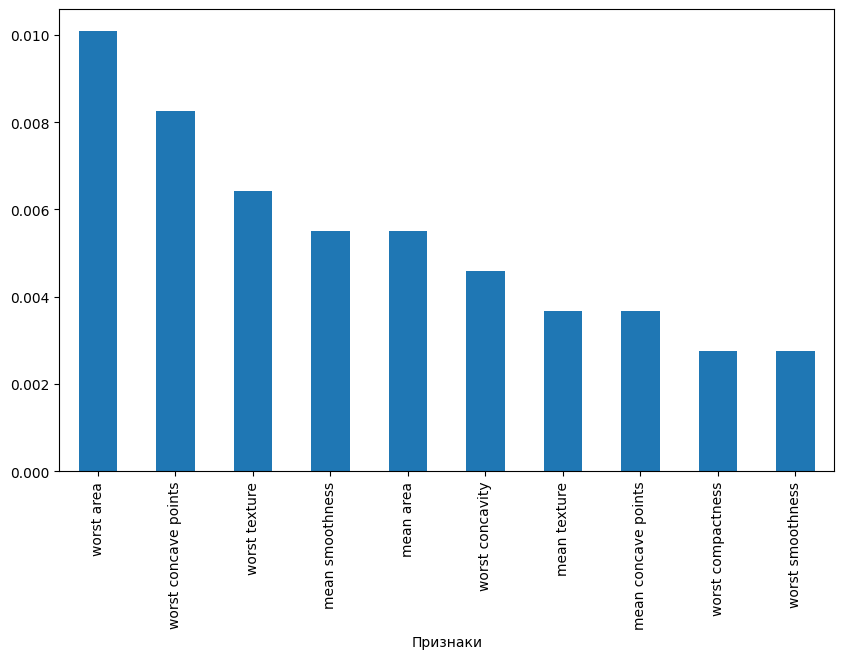

In [9]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42, scoring='f1_macro')

# Построим bar plot топ-10 признаков
# YOUR CODE HERE
importances = pd.Series(pi_result.importances_mean, index=X_test.columns)
top_10_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_10_features.plot(kind='bar')
plt.xlabel('Признаки')
plt.show()

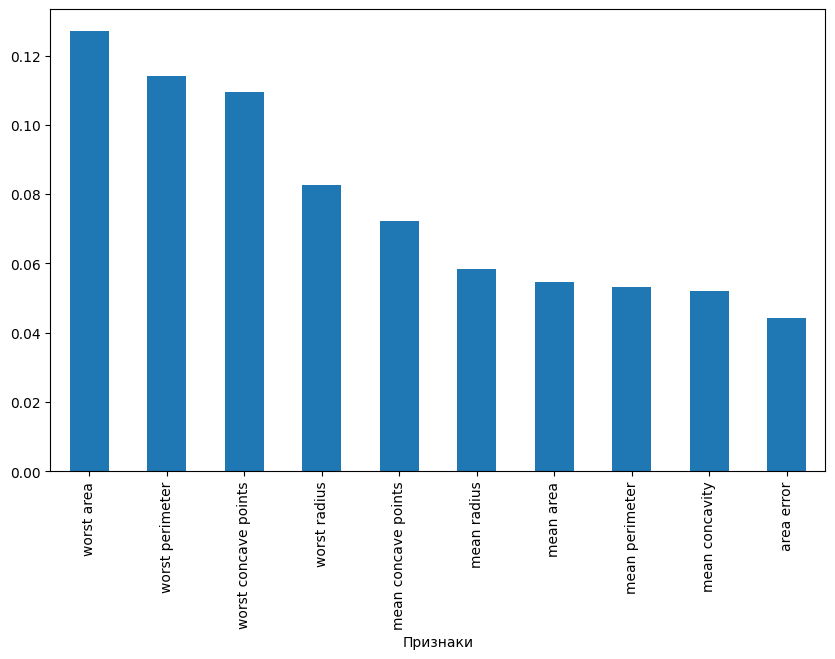

In [10]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝
# не совпадает, так как feature importances и permutation importance вычисляются по-разному, по-разному реагируют на данные, 
# на их мультиколлинеарность и т.д. К тому же permutation importance считается на test, а feature importances на train.

# YOUR CODE HERE
fi_result = best_rf.feature_importances_
importances = pd.Series(fi_result, index=X_test.columns)
top_10_features_fi = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_10_features_fi.plot(kind='bar')
plt.xlabel('Признаки')
plt.show()

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

# Если наоборот, то скорее всего есть мультиколлинеарность этого признака с другим. 

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

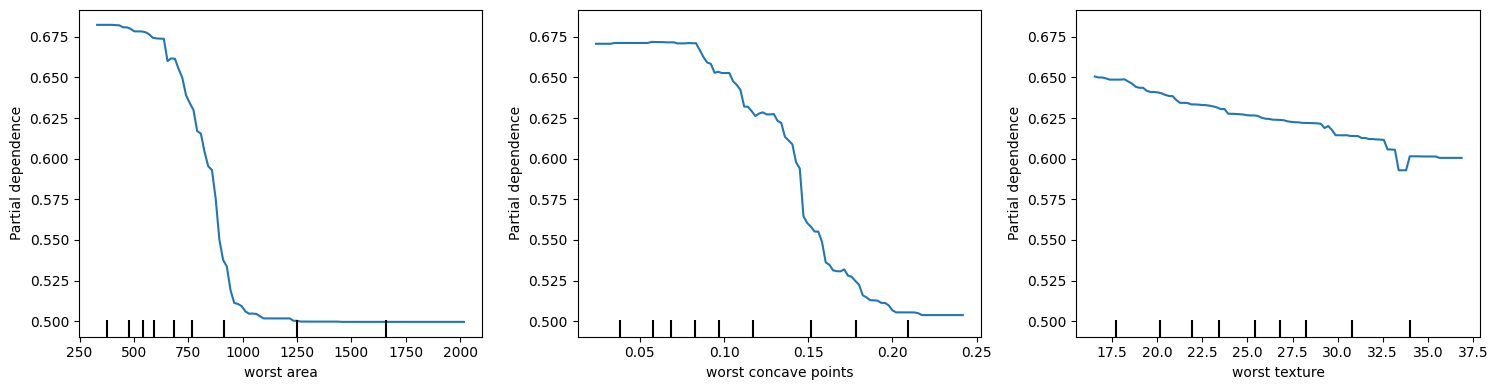

In [11]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = top_10_features.head(3).index.tolist() # YOUR CODE HERE

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
PartialDependenceDisplay.from_estimator(
    estimator=best_rf,
    X=X_train,
    features=top3_idx,
    kind='average',
    ax=ax
)

plt.tight_layout()
plt.show()

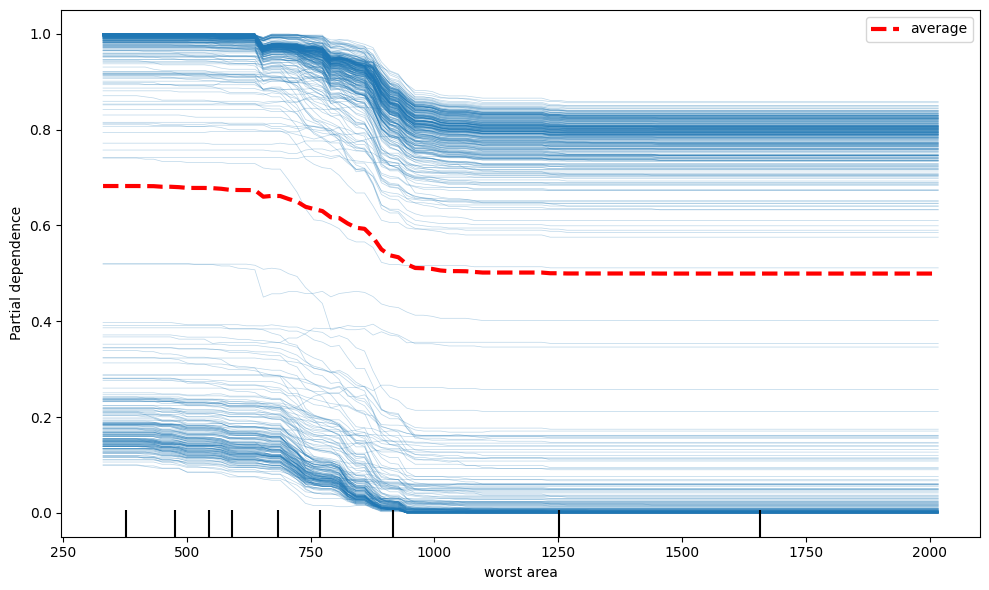

In [12]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)    ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
most_important_feature = top3_idx[0]

fig, ax = plt.subplots(figsize=(10, 6))

PartialDependenceDisplay.from_estimator(
    estimator=best_rf,
    X=X_train,
    features=[most_important_feature],
    kind='both',
    ax=ax,
    pd_line_kw={"color": "red", "linewidth": 3}
)

plt.tight_layout()
plt.show()

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [13]:
# Установка SHAP (если не установлен)
%pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
shap_values.shape

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


(114, 30, 2)

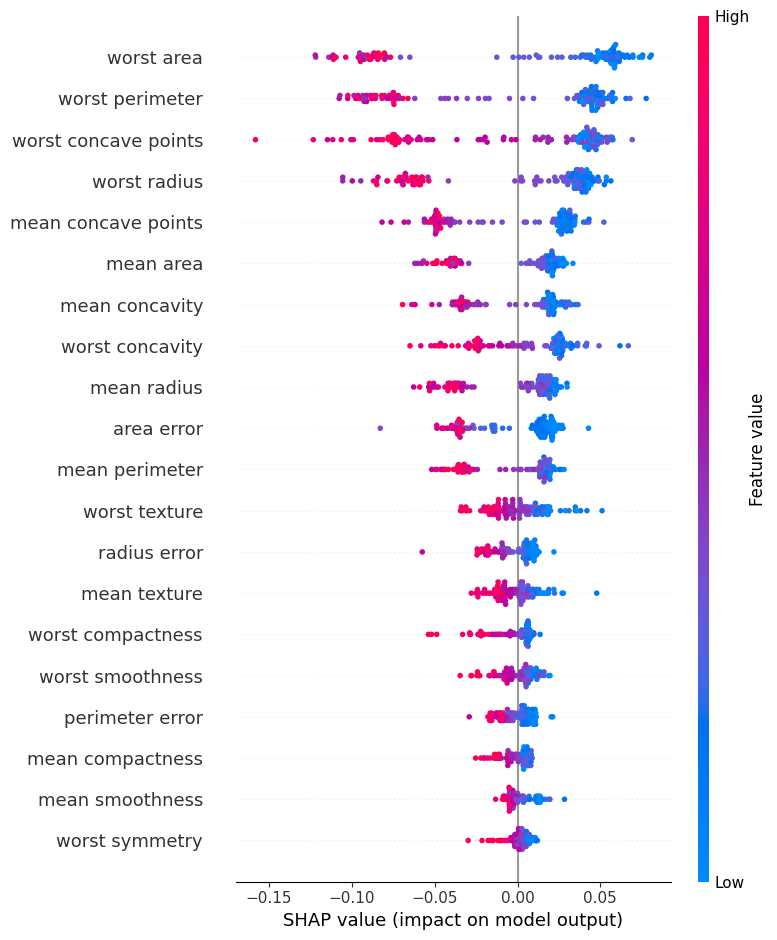

In [14]:
    # ╔══════════════════════════════════════════════════════════════╗
    # ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
    # ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
    # ║  Ответьте: какие признаки самые важные по SHAP?              ║
    # ║  Совпадает ли с PI из шага 6?                                ║
    # ╚══════════════════════════════════════════════════════════════╝
# самые важные: worst area, worst perimeter, worst concave points. С PI не совпадают.

    # YOUR CODE HERE
shap.summary_plot(shap_values[:, :, 1], X_test)

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


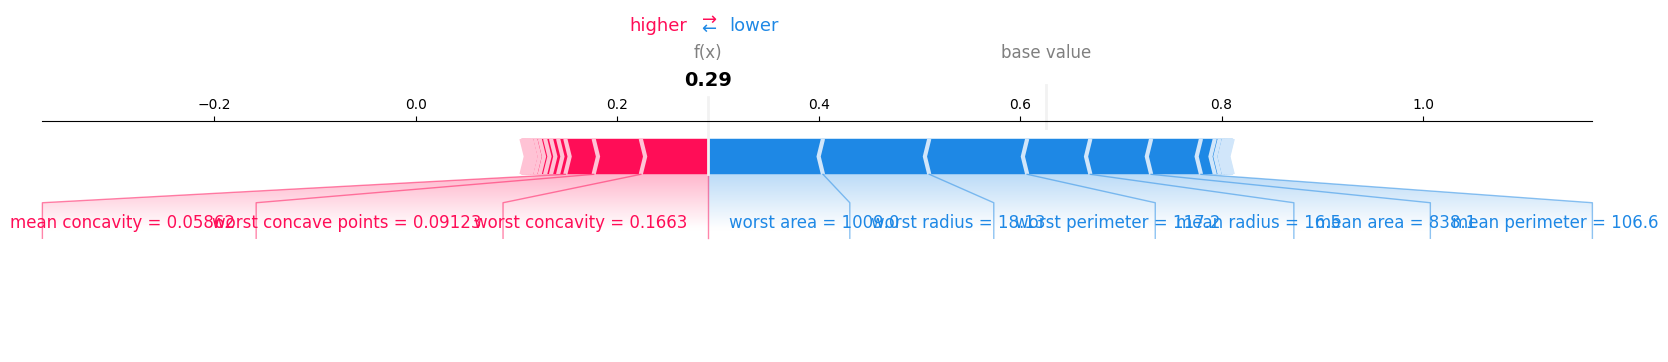

In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝
# worst area, worst radius и worst perimeter

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
error_idx = errors[0]

shap.force_plot(
    base_value=explainer.expected_value[1],
    shap_values=shap_values[error_idx, :, 1],
    features=X_test.iloc[error_idx],
    matplotlib=True
)

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [16]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

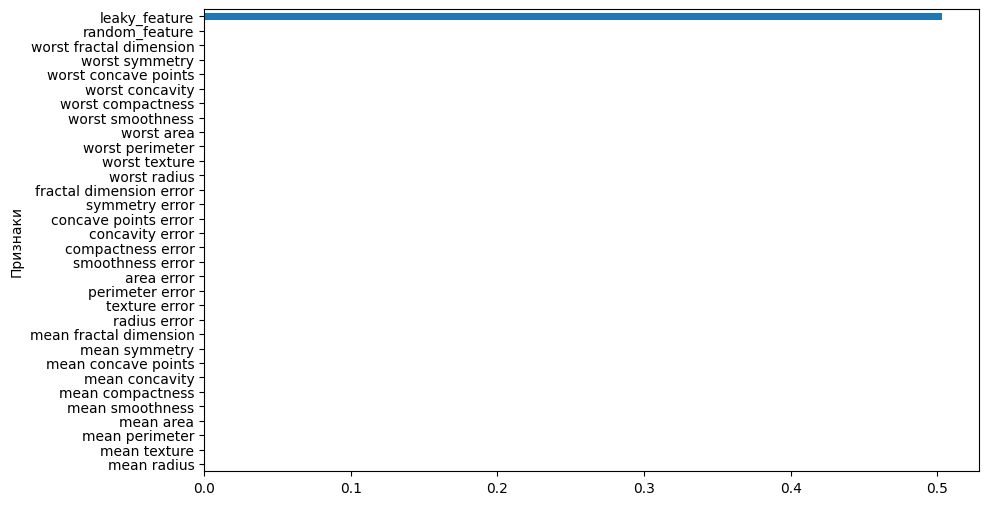

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝
# а) определяет как единственный важный признак, что логично, зная природу PI. Метрика выросла, так как если убрать любой другой признак, 
# то будет легко однозначно установить соответствие определенному классу по данному признаку. Но если удалить этот признак, то модель может 
# допустить ошибку.
# б) Четко видно, что все синие слева, а все красные справа от вертикальной прямой, что значит, что по этому признаку можно легко (в д.сл. однозначно) 
# определить принадлежность к классу.
# в) надо удалить leaky feature, чтобы увидеть разницу в PI между всеми признаками и random feature

# YOUR CODE HERE
rf_random_search.fit(X_train_ext, y_train)
best_rf = rf_random_search.best_estimator_
pi_result = permutation_importance(best_rf, X_test_ext, y_test, n_repeats=10, random_state=42, scoring='f1_macro')
importances = pd.Series(pi_result.importances_mean, index=X_test_ext.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.ylabel('Признаки')
plt.show()

In [19]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_ext)
shap_values.shape


(114, 32, 2)

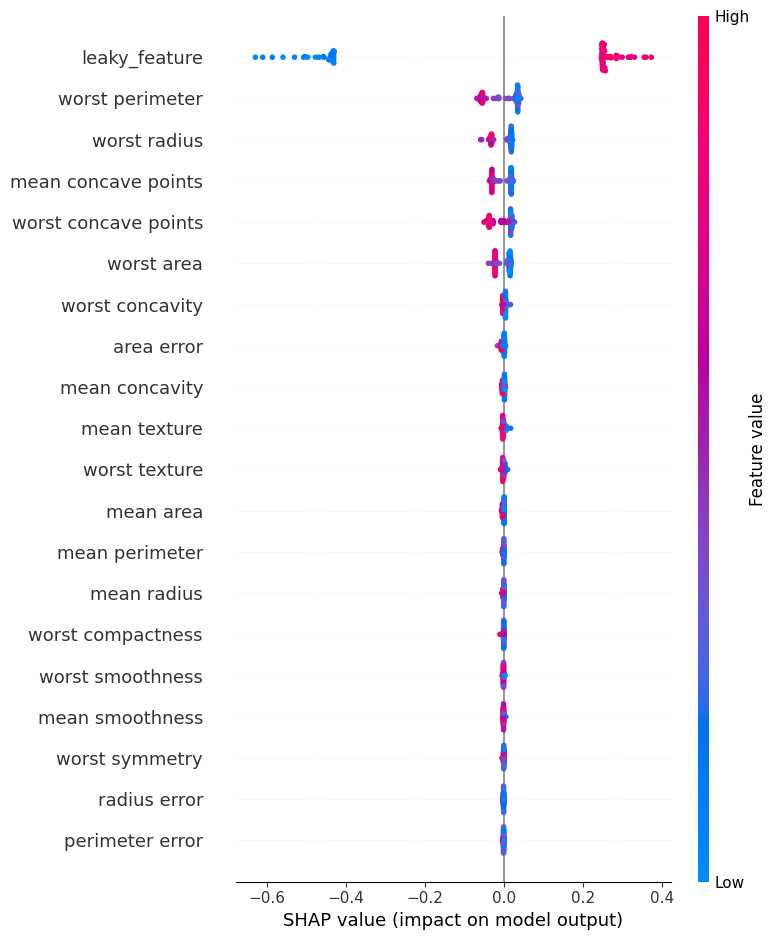

In [21]:
shap.summary_plot(shap_values[:, :, 1], X_test_ext)

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [24]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
comparison_table['Выводы'] = [
    'Показывает отличный базовый результат. Модель изначально стабильна, а метрика на тесте даже выше, чем на кросс-валидации, что говорит о хорошей обобщающей способности.', 
    'Подбор гиперпараметров помог немного поднять средний CV F1 и снизить разброс. Результат на тесте совпал с baseline.',
    'Работает чуть хуже, чем SVM, и имеет более высокий разброс на кросс-валидации из-за стохастической природы алгоритма.',
    'Подбро гиперпараметров помог сгладить переобучение - CV F1 вырос, а разброс уменьшился. На тесте метрика осталась прежней, так как структура ключевых разделений в деревьях не изменилась.'
    ]
comparison_table

,Модель,CV F1 (mean±std),Test F1,Выводы
0,SVM baseline,0.9694±0.0193,0.981151,Показывает отличный базовый результат. Модель ...
1,SVM Grid Search,0.9786±0.0176,0.981151,Подбор гиперпараметров помог немного поднять с...
2,RF baseline,0.9504±0.0255,0.952638,"Работает чуть хуже, чем SVM, и имеет более выс..."
3,RF Random Search,0.9554±0.0204,0.952638,Подбро гиперпараметров помог сгладить переобуч...


1. Тюнинг заметно улучшил модели, что я написал в выводах в первой и третьей строках таблицы. Увеличился mean CV F1 и уменьшился разброс.
2. Не совпадают, так как алгоритмы работают по-разному. SHAP лучше работает с коррелированными признаками, тогда как PI занижает их важность.
3. Могли бы запутаться в предобработке данных для модели и могли бы получить утечку данных.
4. PI я бы использовал на заведомо чистом датасете (без корреляций), либо в купе с просмотром тепловой карты, либо, когда надо быстро прикинуть. В остальных же случаях я бы использовал SHAP.

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [ ]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")